Lab 2: Classification Problem

Objective:
The purpose of this Lab is to give you practice with building and evaluating classification models using Python. You will use a dataset of your choice to compare three popular classification algorithms: Logistic Regression, k-Nearest Neighbors (k-NN), and Decision Trees. You will evaluate the performance of each model using metrics such as accuracy, precision, recall, and F1-score.


In [1]:
# import packages
import pandas as pd
import numpy as np

# load data set
df_iris = pd.read_csv('C:\\Users\\odellj\\OneDrive - Northwood University\\Documents\\MSBA\\MGT 665 Solv Probs w Machine Learning\\Iris Dataset\\iris.csv')

In [2]:
#Build a Logistic Regression model
#import packages for logistic regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

In [3]:
df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Prepare the data
# Split the data into features (X) and target (y):
X = df_iris.drop('species', axis=1)
y = df_iris['species']

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [11]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: species
Non-Null Count  Dtype 
--------------  ----- 
150 non-null    object
dtypes: object(1)
memory usage: 1.3+ KB


In [13]:
# Split the data into training and testing sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Initialize the logistic regression model with multinomial option
log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# Fit the model to the training data:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [15]:
log_model.predict(X_test)

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

In [16]:
log_model.score(X_test, y_test)

1.0

Based on the score function, it tells us the model is able to correctly predict every instance in our test data.

In [19]:
# Predict and evaluate
y_pred = log_model.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

In [21]:
report = classification_report(y_test, y_pred)

In [23]:
# Print results

print(f"Logistic Regression Accuracy: {accuracy:.2f}")
print(f"Confustion Matrix:\n{conf_mat}")
print(f"Classification Report:\n{report}")

Logistic Regression Accuracy: 1.00
Confustion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



These metrics tell us that this multinomial logistic regression model correctly predicted every test instance correctly. 
Accuracy: the proportion of correct instances were 100% of the total instances
Precision: every instances that were predicted as positive were predicted correctly
Recall: every positive instances were predicted as positive
F1-score: balance between Recall and Precision is also 100% accurate

In [24]:
#Build a K-nearest neighbor model
#import packages for KNN

from sklearn.neighbors import KNeighborsClassifier


In [25]:
# Train the k-NN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [26]:
# Predict and evaluate
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_mat_knn = confusion_matrix(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

In [27]:
# Print results

print(f"Logistic Regression Accuracy: {accuracy_knn:.2f}")
print(f"Confustion Matrix:\n{conf_mat_knn}")
print(f"Classification Report:\n{report_knn}")

Logistic Regression Accuracy: 1.00
Confustion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



These metrics tell us that this K-NN model correctly predicted every test instance correctly. 
Accuracy: the proportion of correct instances were 100% of the total instances
Precision: every instances that were predicted as positive were predicted correctly
Recall: every positive instances were predicted as positive
F1-score: balance between Recall and Precision is also 100% accurate

In [30]:
#Build a Decision Tree model
#import packages for Decision Trees

from sklearn.tree import DecisionTreeClassifier

In [31]:
# Train the Decision Tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [32]:
# Check Model Accuracy
clf.score(X_test, y_test)

1.0

In [33]:
# Visualize the tree
from sklearn import tree
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

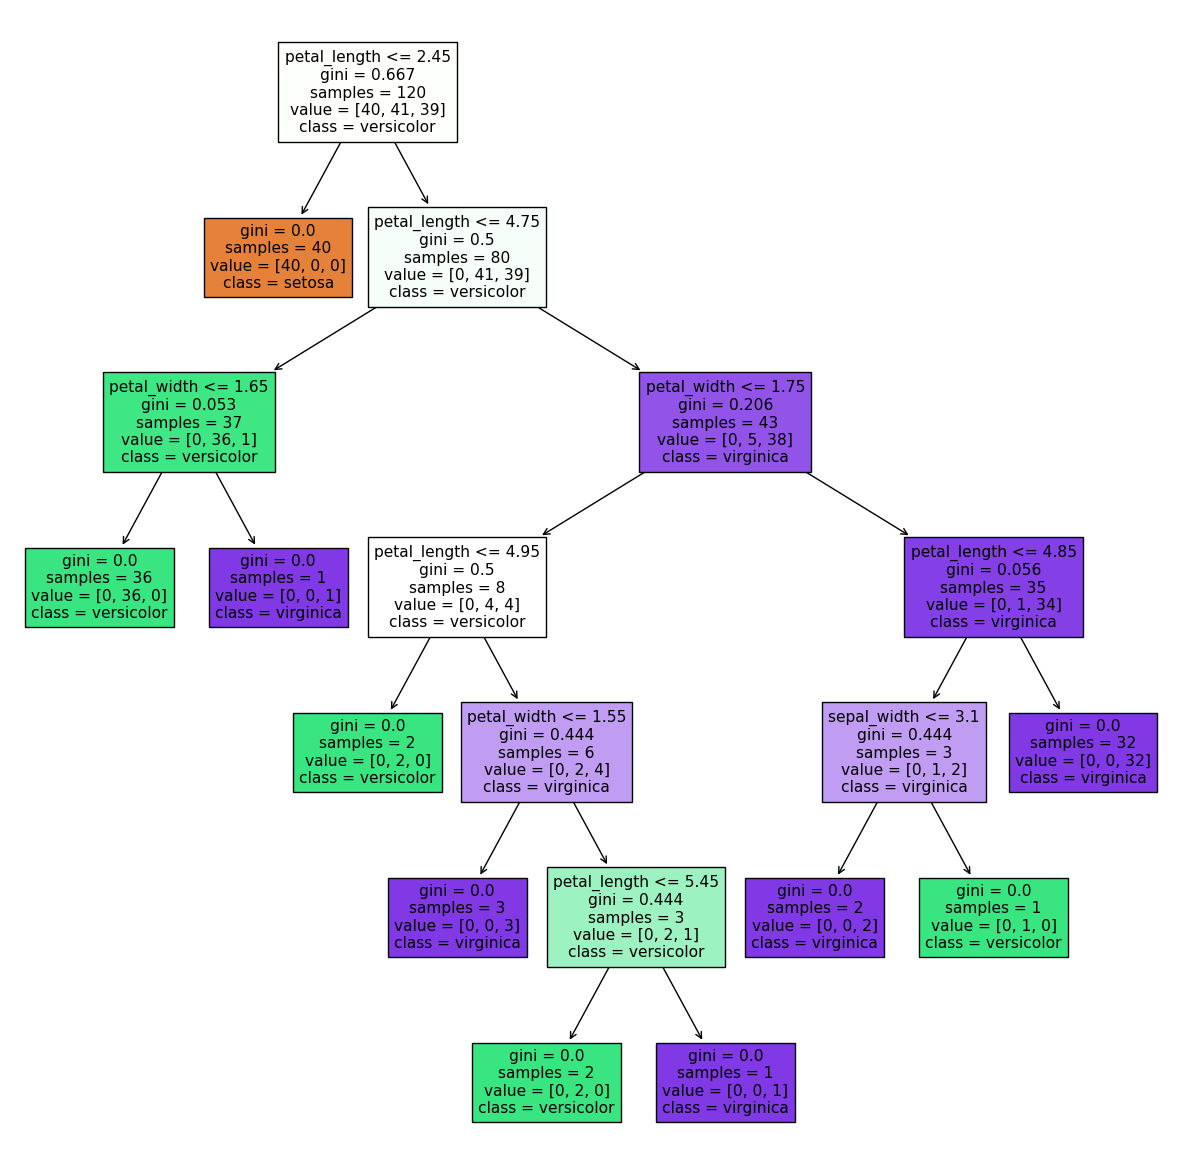

In [34]:
plt.figure(figsize = (15,15))
tree.plot_tree(clf, feature_names = list(X.columns), class_names = ['setosa', 'versicolor', 'virginica'], filled = True);

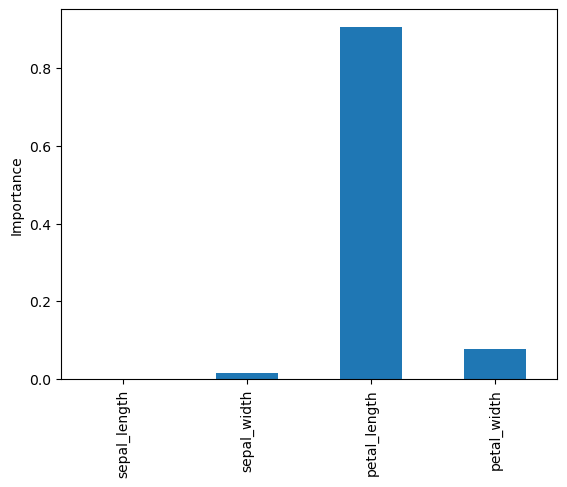

In [39]:
importance = clf.feature_importances_
feature_importance = pd.Series(importance, index = X.columns)
feature_importance.plot(kind = 'bar')
plt.ylabel('Importance');

In [40]:
clf.score(X_train, y_train)

1.0

In [41]:
clf.score(X_test, y_test)

1.0

In [43]:
# Prune the decision tree
# I will begin to modify the hyperparameters

grid = {'max_depth': [2, 3, 4, 5], 
        'min_samples_split': [2, 3, 4], 
        'min_samples_leaf': [1, 2, 3, 4, 5, 6]}

In [44]:
# perform grid search to identify best hyperparameters
from sklearn.model_selection import GridSearchCV
classifier = DecisionTreeClassifier(random_state = 1234)
gcv = GridSearchCV(estimator = classifier, param_grid = grid)
gcv.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=1234),
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6],
                         'min_samples_split': [2, 3, 4]})

In [45]:
# fit the grid search model
model_ = gcv.best_estimator_
model_.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=3, random_state=1234)

In [46]:
# score the grid search model on the training data
model_.score(X_train, y_train)

0.9666666666666667

Here we find that the model accuracy on the Training data has gone down slightly.

In [47]:
# score the grid search model on the test data
model_.score(X_test, y_test)

1.0

Despite the accuracy on the training data going down, the test data remains at 100% accuracy.

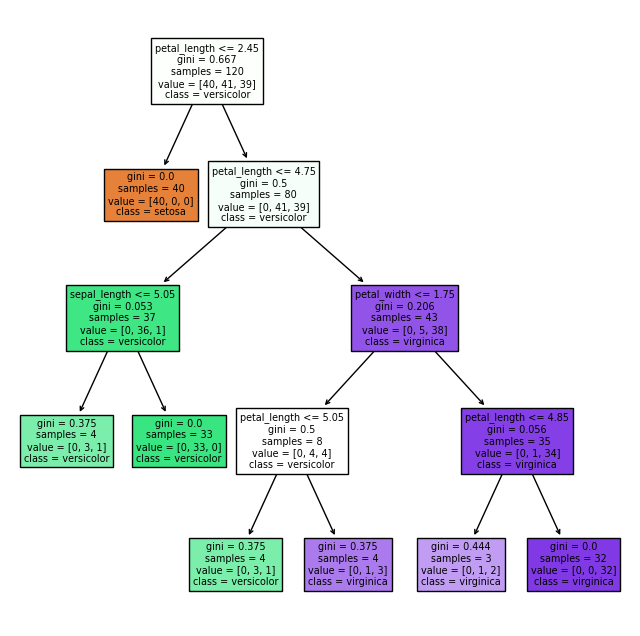

In [48]:
# visualize the new decision tree
plt.figure(figsize = (8,8))
tree.plot_tree(model_, 
               feature_names = list(X.columns), 
               class_names = ['setosa', 'versicolor', 'virginica'], 
               filled = True);

In [49]:
# Predict and evaluate
y_pred_dt = model_.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
conf_mat_dt = confusion_matrix(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

In [50]:
# Print results

print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
print(f"Confustion Matrix:\n{conf_mat_dt}")
print(f"Classification Report:\n{report_dt}")

Decision Tree Accuracy: 1.00
Confustion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Model Evaluation:
The decision tree once again provided 100% accuracy on all metrics. 

Comparison:
It is impossible to compare these three models performance since they all performed identically. With identical scores there are no contrasts in strengths and weaknesses. This is highly suspicious and worth further review.